In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn imbalanced-learn optuna torch torchvision torchaudio pytorch-tabnet
!pip install einops tqdm


DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/lightning_utilities-0.11.9-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/opt_einsum-3.4.0-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/dill-0.3.9-py3.12.egg is deprecated. pip 25.1 will enforce this behaviour change. A possible replacement is to use pip for package installation. Discussion can be found at https://github.com/pypa/pip/issues/12330
DEPRECATION: Loading egg at /usr/local/lib/python3.12/dist-packages/igraph-0.11.8-py3.12-linux-x86_64.egg is deprecated. pip 25.1 will 

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from imblearn.over_sampling import SMOTE
from tqdm import tqdm
import optuna
import warnings
warnings.filterwarnings("ignore")


In [3]:
df = pd.read_csv("cleaned_merged_heart_dataset.csv")  # Replace with actual file name
print("Shape:", df.shape)
df.head()


Shape: (1888, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalachh,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


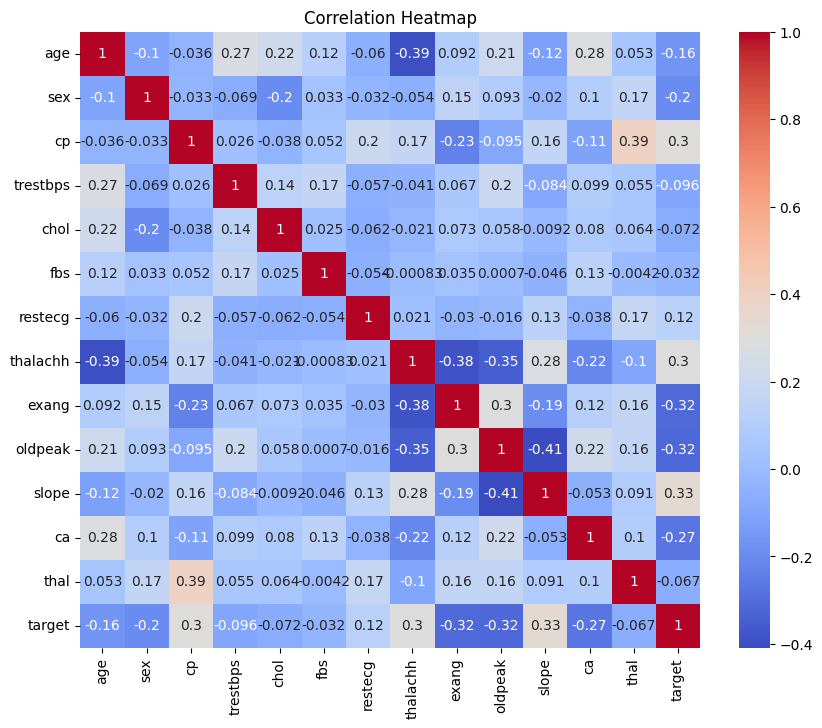

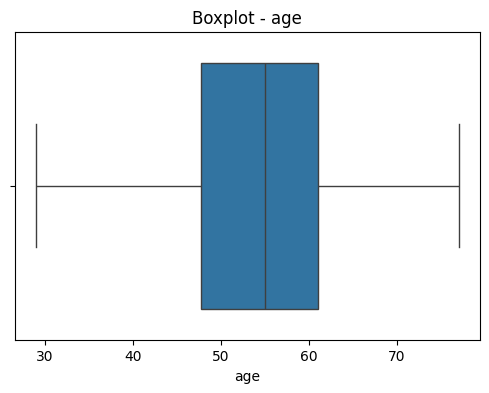

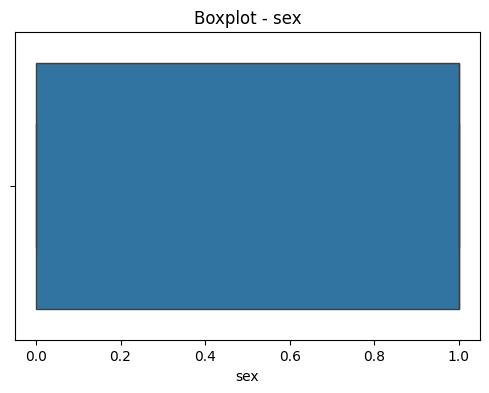

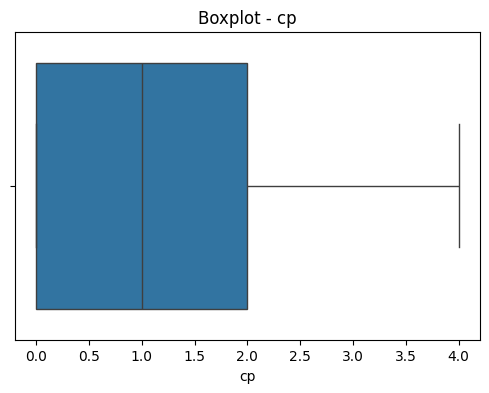

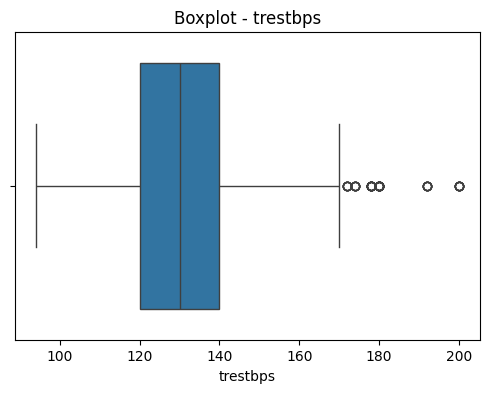

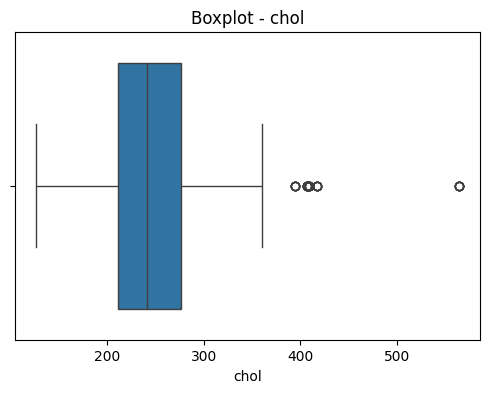

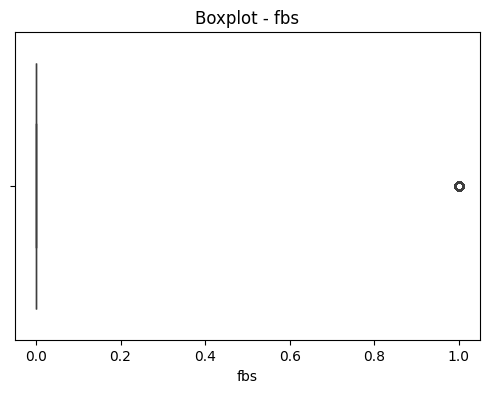

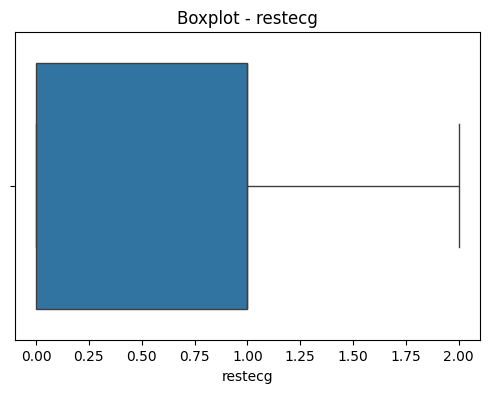

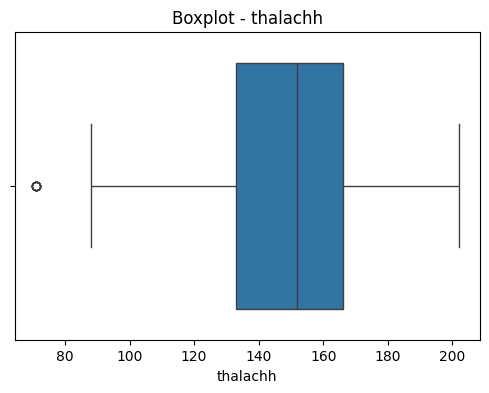

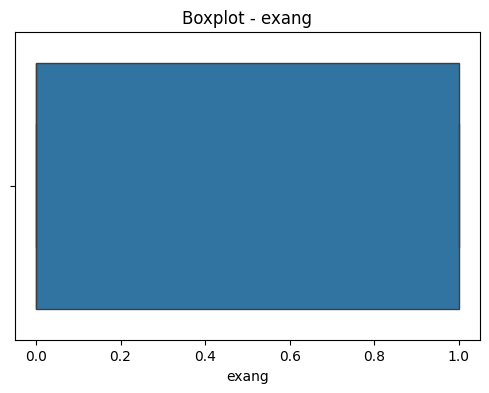

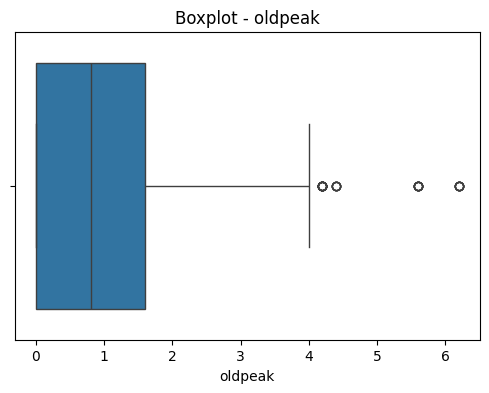

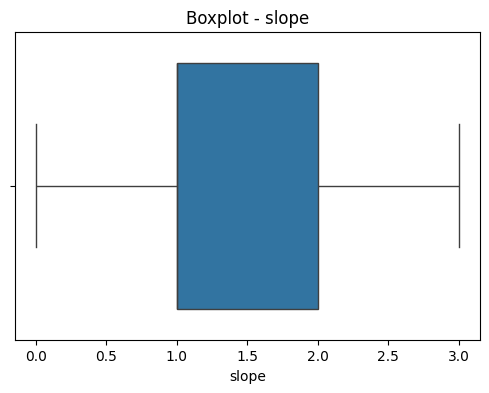

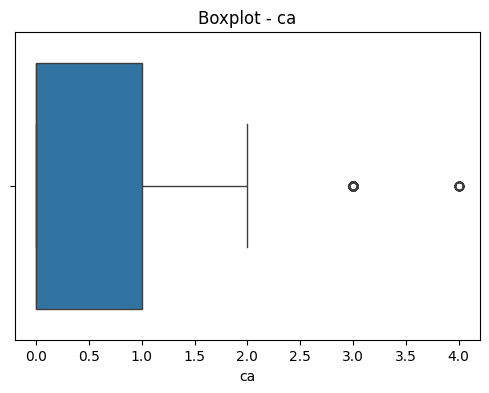

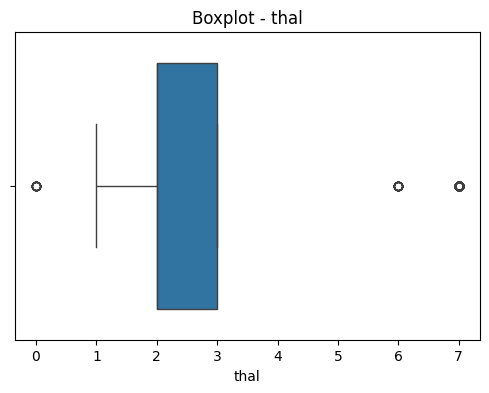

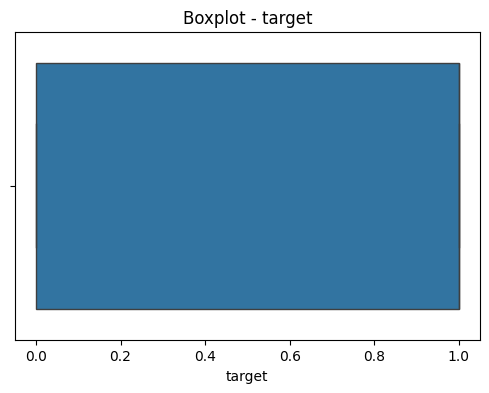

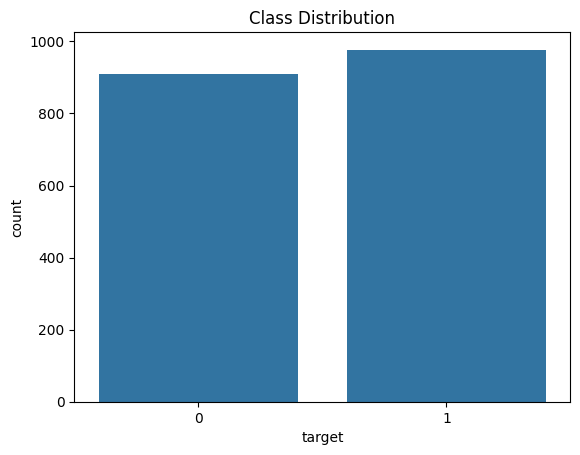

target
1    51.747881
0    48.252119
Name: proportion, dtype: float64


In [4]:
# Correlation Heatmap
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

# Boxplots for each feature
for col in df.columns:
    if df[col].dtype != 'object':
        plt.figure(figsize=(6,4))
        sns.boxplot(x=df[col])
        plt.title(f"Boxplot - {col}")
        plt.show()

# Class Imbalance Check
sns.countplot(x=df['target'])
plt.title("Class Distribution")
plt.show()
print(df['target'].value_counts(normalize=True)*100)


In [5]:
# Label Encoding for binary categorical
le = LabelEncoder()
for col in df.select_dtypes(include=['object']).columns:
    if df[col].nunique() == 2:
        df[col] = le.fit_transform(df[col])

# One Hot Encoding for multi-class categorical
df = pd.get_dummies(df, drop_first=True)

# Features and Target
X = df.drop("target", axis=1)
y = df["target"]

# SMOTE for balancing
sm = SMOTE(random_state=42)
X_res, y_res = sm.fit_resample(X, y)

# Noise reduction (Gaussian smoothing)
from scipy.ndimage import gaussian_filter
X_res = pd.DataFrame(gaussian_filter(X_res, sigma=0.5), columns=X.columns)

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)

# Standard Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train.values, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test.values, dtype=torch.float32)


In [6]:
class AutoEncoder(nn.Module):
    def __init__(self, input_dim, bottleneck_dim=8):
        super(AutoEncoder, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, bottleneck_dim)
        )
        self.decoder = nn.Sequential(
            nn.Linear(bottleneck_dim, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )
    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon, z

autoencoder = AutoEncoder(X_train.shape[1], bottleneck_dim=8)
criterion = nn.MSELoss()
optimizer = optim.Adam(autoencoder.parameters(), lr=0.001)

for epoch in range(50):
    optimizer.zero_grad()
    recon, _ = autoencoder(X_train_tensor)
    loss = criterion(recon, X_train_tensor)
    loss.backward()
    optimizer.step()

# Get reduced features
with torch.no_grad():
    _, X_train_reduced = autoencoder(X_train_tensor)
    _, X_test_reduced = autoencoder(X_test_tensor)


In [7]:
class NODELayer(nn.Module):
    def __init__(self, in_dim, out_dim):
        super(NODELayer, self).__init__()
        self.fc = nn.Linear(in_dim, out_dim)
    def forward(self, x):
        return torch.relu(self.fc(x))

class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, heads):
        super(TransformerBlock, self).__init__()
        self.attn = nn.MultiheadAttention(embed_dim, heads, batch_first=True)
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, 128),
            nn.ReLU(),
            nn.Linear(128, embed_dim)
        )
    def forward(self, x):
        attn_output, _ = self.attn(x, x, x)
        x = x + attn_output
        x = x + self.ff(x)
        return x

class NODETransformer(nn.Module):
    def __init__(self, input_dim, node_dim=32, embed_dim=32, heads=4):
        super(NODETransformer, self).__init__()
        self.node = NODELayer(input_dim, node_dim)
        self.transformer = TransformerBlock(embed_dim, heads)
        self.fc_out = nn.Linear(embed_dim, 1)
    def forward(self, x):
        x = self.node(x)
        x = x.unsqueeze(1)
        x = self.transformer(x)
        x = x.squeeze(1)
        return torch.sigmoid(self.fc_out(x))

model = NODETransformer(input_dim=X_train_reduced.shape[1]).cuda()
criterion = nn.BCELoss()
optimizer = optim.AdamW(model.parameters(), lr=0.001)

for epoch in range(50):
    optimizer.zero_grad()
    outputs = model(X_train_reduced.cuda())
    loss = criterion(outputs.squeeze(), y_train_tensor.cuda())
    loss.backward()
    optimizer.step()
    if (epoch+1)%10==0:
        print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")


Epoch 10, Loss: 0.6309
Epoch 20, Loss: 0.6096
Epoch 30, Loss: 0.5953
Epoch 40, Loss: 0.5847
Epoch 50, Loss: 0.5712


              precision    recall  f1-score   support

           0       0.65      0.75      0.70       191
           1       0.72      0.61      0.66       200

    accuracy                           0.68       391
   macro avg       0.68      0.68      0.68       391
weighted avg       0.69      0.68      0.68       391



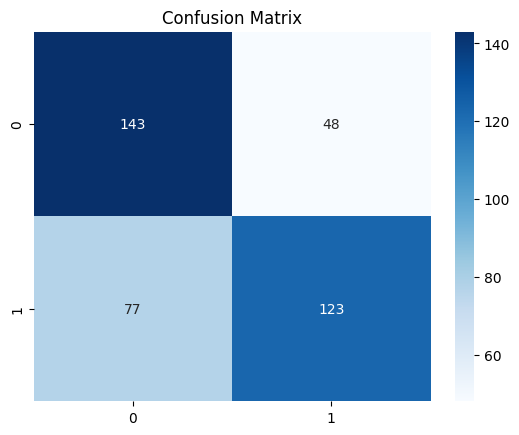

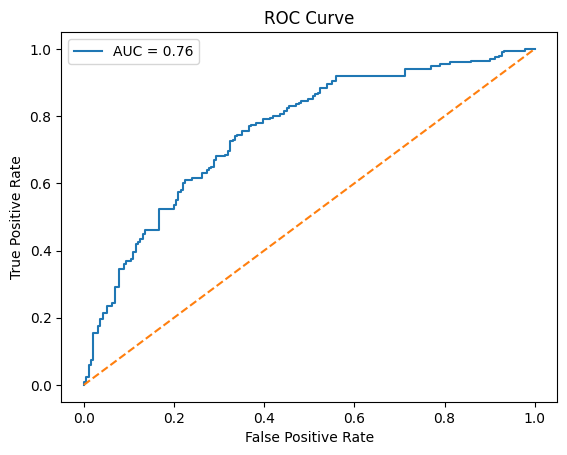

In [8]:
model.eval()
with torch.no_grad():
    preds = model(X_test_reduced.cuda()).cpu().numpy()
preds_binary = (preds > 0.5).astype(int)

print(classification_report(y_test, preds_binary))

cm = confusion_matrix(y_test, preds_binary)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()

fpr, tpr, _ = roc_curve(y_test, preds)
roc_auc = auc(fpr, tpr)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1],[0,1],'--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()


In [13]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, roc_curve, auc, roc_auc_score
import optuna


In [14]:
# -----------------------
# Transformer Block
# -----------------------
class TransformerBlock(nn.Module):
    def __init__(self, embed_dim, heads, dropout=0.1):
        super().__init__()
        self.attn = nn.MultiheadAttention(embed_dim, heads, batch_first=True)
        self.norm1 = nn.LayerNorm(embed_dim)
        self.norm2 = nn.LayerNorm(embed_dim)
        self.ff = nn.Sequential(
            nn.Linear(embed_dim, embed_dim * 2),
            nn.ReLU(),
            nn.Linear(embed_dim * 2, embed_dim),
            nn.Dropout(dropout)
        )
    def forward(self, x):
        attn_output, _ = self.attn(x, x, x)
        x = self.norm1(x + attn_output)
        ff_output = self.ff(x)
        x = self.norm2(x + ff_output)
        return x

# -----------------------
# Focal Loss
# -----------------------
class FocalLoss(nn.Module):
    def __init__(self, alpha=1, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.bce = nn.BCELoss()
    def forward(self, inputs, targets):
        bce_loss = self.bce(inputs, targets)
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        return focal_loss

# -----------------------
# NODE + Transformer Hybrid
# -----------------------
class NODETransformer(nn.Module):
    def __init__(self, input_dim, node_dim=128, heads=8, dropout=0.2):
        super().__init__()
        self.node = nn.Sequential(
            nn.Linear(input_dim, node_dim),
            nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.transformer1 = TransformerBlock(node_dim, heads, dropout)
        self.transformer2 = TransformerBlock(node_dim, heads, dropout)
        self.fc_out = nn.Linear(node_dim, 1)
    def forward(self, x):
        x = self.node(x)
        x = x.unsqueeze(1)
        x = self.transformer1(x)
        x = self.transformer2(x)
        x = x.squeeze(1)
        return torch.sigmoid(self.fc_out(x))


In [15]:
# -----------------------
# Optuna Objective Function
# -----------------------
def objective(trial):
    node_dim = trial.suggest_categorical('node_dim', [64, 128, 256])
    heads = trial.suggest_categorical('heads', [4, 8])
    dropout = trial.suggest_uniform('dropout', 0.0, 0.5)
    lr = trial.suggest_loguniform('lr', 1e-5, 1e-2)
    batch_size = trial.suggest_categorical('batch_size', [32, 64, 128])
    weight_decay = trial.suggest_loguniform('weight_decay', 1e-6, 1e-2)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = NODETransformer(input_dim=X_train.shape[1], node_dim=node_dim, heads=heads, dropout=dropout).to(device)
    bce_loss = nn.BCELoss()
    focal_loss = FocalLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32).to(device),
                                  torch.tensor(y_train.values, dtype=torch.float32).to(device))
    test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32).to(device),
                                 torch.tensor(y_test.values, dtype=torch.float32).to(device))
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    for epoch in range(25):  # Short training for tuning
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad()
            outputs = model(xb).squeeze()
            loss = 0.5 * bce_loss(outputs, yb) + 0.5 * focal_loss(outputs, yb)
            loss.backward()
            optimizer.step()

    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            out = model(xb).squeeze()
            preds.extend(out.cpu().numpy())
            targets.extend(yb.cpu().numpy())
    return roc_auc_score(targets, preds)

In [16]:
# -----------------------
# Run Optuna Tuning
# -----------------------
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=40)
print("Best parameters:", study.best_params)
print("Best AUC:", study.best_value)


[I 2025-08-03 19:27:39,649] A new study created in memory with name: no-name-07c9d02e-9ba9-4f93-a4ab-0b4cddd6ad3a
[I 2025-08-03 19:27:41,348] Trial 0 finished with value: 0.837303664921466 and parameters: {'node_dim': 64, 'heads': 8, 'dropout': 0.27992391570975744, 'lr': 3.802161261281469e-05, 'batch_size': 128, 'weight_decay': 9.363158319855146e-05}. Best is trial 0 with value: 0.837303664921466.
[I 2025-08-03 19:27:43,033] Trial 1 finished with value: 0.9820418848167539 and parameters: {'node_dim': 256, 'heads': 8, 'dropout': 0.27409612997107285, 'lr': 0.0023498055687230946, 'batch_size': 128, 'weight_decay': 0.0001269938127935485}. Best is trial 1 with value: 0.9820418848167539.
[I 2025-08-03 19:27:48,478] Trial 2 finished with value: 0.8383769633507854 and parameters: {'node_dim': 64, 'heads': 8, 'dropout': 0.40349453140521796, 'lr': 3.334515785953595e-05, 'batch_size': 32, 'weight_decay': 0.00010090425457043527}. Best is trial 1 with value: 0.9820418848167539.
[I 2025-08-03 19:27:

Best parameters: {'node_dim': 128, 'heads': 4, 'dropout': 0.08284526173495126, 'lr': 0.0010023058938669748, 'batch_size': 64, 'weight_decay': 3.371184767505159e-05}
Best AUC: 0.9943979057591622


Epoch 1 - Loss: 0.2992 - Val AUC: 0.9092
Epoch 2 - Loss: 0.2232 - Val AUC: 0.9282
Epoch 3 - Loss: 0.1934 - Val AUC: 0.9344
Epoch 4 - Loss: 0.1777 - Val AUC: 0.9487
Epoch 5 - Loss: 0.1447 - Val AUC: 0.9590
Epoch 6 - Loss: 0.1347 - Val AUC: 0.9639
Epoch 7 - Loss: 0.1151 - Val AUC: 0.9715
Epoch 8 - Loss: 0.1071 - Val AUC: 0.9742
Epoch 9 - Loss: 0.0952 - Val AUC: 0.9744
Epoch 10 - Loss: 0.0950 - Val AUC: 0.9765
Epoch 11 - Loss: 0.1373 - Val AUC: 0.9615
Epoch 12 - Loss: 0.1230 - Val AUC: 0.9737
Epoch 13 - Loss: 0.1172 - Val AUC: 0.9753
Epoch 14 - Loss: 0.0832 - Val AUC: 0.9774
Epoch 15 - Loss: 0.0805 - Val AUC: 0.9802
Epoch 16 - Loss: 0.0823 - Val AUC: 0.9779
Epoch 17 - Loss: 0.0728 - Val AUC: 0.9811
Epoch 18 - Loss: 0.0684 - Val AUC: 0.9875
Epoch 19 - Loss: 0.0471 - Val AUC: 0.9904
Epoch 20 - Loss: 0.0476 - Val AUC: 0.9853
Epoch 21 - Loss: 0.0429 - Val AUC: 0.9897
Epoch 22 - Loss: 0.0406 - Val AUC: 0.9880
Epoch 23 - Loss: 0.0395 - Val AUC: 0.9903
Epoch 24 - Loss: 0.0305 - Val AUC: 0.9902
E

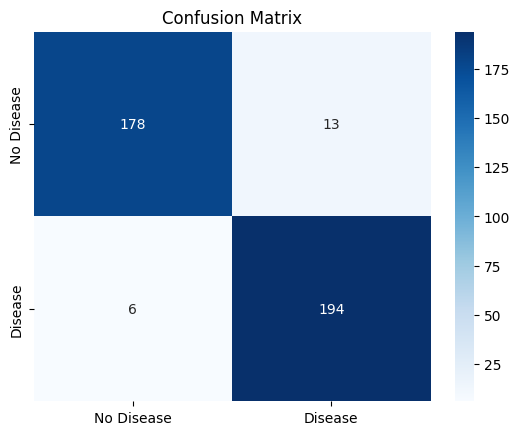

Accuracy     : 0.9514
Precision    : 0.9372
Recall       : 0.9700
Specificity  : 0.9319
F1 Score     : 0.9533
AUC-ROC      : 0.9926


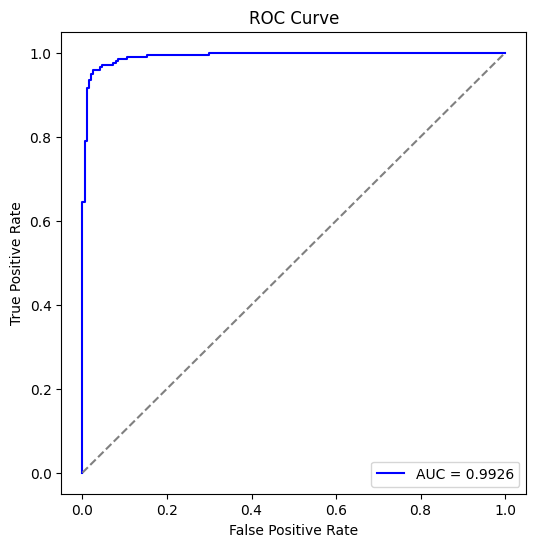

In [17]:
# -----------------------
# Train Final Model with Best Params
# -----------------------
best_params = study.best_params
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = NODETransformer(input_dim=X_train.shape[1],
                         node_dim=best_params['node_dim'],
                         heads=best_params['heads'],
                         dropout=best_params['dropout']).to(device)

bce_loss = nn.BCELoss()
focal_loss = FocalLoss()
optimizer = optim.AdamW(model.parameters(), lr=best_params['lr'], weight_decay=best_params['weight_decay'])
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(optimizer, T_0=10, T_mult=2)

train_dataset = TensorDataset(torch.tensor(X_train, dtype=torch.float32).to(device),
                              torch.tensor(y_train.values, dtype=torch.float32).to(device))
test_dataset = TensorDataset(torch.tensor(X_test, dtype=torch.float32).to(device),
                             torch.tensor(y_test.values, dtype=torch.float32).to(device))
train_loader = DataLoader(train_dataset, batch_size=best_params['batch_size'], shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=best_params['batch_size'], shuffle=False)

best_auc = 0
patience = 15
no_improve_epochs = 0

for epoch in range(150):
    model.train()
    train_losses = []
    for xb, yb in train_loader:
        optimizer.zero_grad()
        outputs = model(xb).squeeze()
        loss = 0.5 * bce_loss(outputs, yb) + 0.5 * focal_loss(outputs, yb)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())
    scheduler.step()

    model.eval()
    preds, targets = [], []
    with torch.no_grad():
        for xb, yb in test_loader:
            out = model(xb).squeeze()
            preds.extend(out.cpu().numpy())
            targets.extend(yb.cpu().numpy())
    auc_score = roc_auc_score(targets, preds)
    print(f"Epoch {epoch+1} - Loss: {np.mean(train_losses):.4f} - Val AUC: {auc_score:.4f}")

    if auc_score > best_auc:
        best_auc = auc_score
        torch.save(model.state_dict(), "best_model_optuna.pth")
        no_improve_epochs = 0
    else:
        no_improve_epochs += 1
    if no_improve_epochs >= patience:
        print("Early stopping triggered.")
        break

# -----------------------
# Load Best Model & Evaluate
# -----------------------
model.load_state_dict(torch.load("best_model_optuna.pth"))
model.eval()
with torch.no_grad():
    y_pred_probs = model(torch.tensor(X_test, dtype=torch.float32).to(device)).cpu().numpy()
y_pred_binary = (y_pred_probs > 0.5).astype(int)

cm = confusion_matrix(y_test, y_pred_binary)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["No Disease", "Disease"],
            yticklabels=["No Disease", "Disease"])
plt.title("Confusion Matrix")
plt.show()

accuracy = accuracy_score(y_test, y_pred_binary)
precision = precision_score(y_test, y_pred_binary)
recall = recall_score(y_test, y_pred_binary)
specificity = cm[0,0] / (cm[0,0] + cm[0,1])
f1 = f1_score(y_test, y_pred_binary)
fpr, tpr, _ = roc_curve(y_test, y_pred_probs)
roc_auc = auc(fpr, tpr)

print(f"Accuracy     : {accuracy:.4f}")
print(f"Precision    : {precision:.4f}")
print(f"Recall       : {recall:.4f}")
print(f"Specificity  : {specificity:.4f}")
print(f"F1 Score     : {f1:.4f}")
print(f"AUC-ROC      : {roc_auc:.4f}")

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, color='blue', label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend(loc="lower right")
plt.show()
